In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
from utils import plot_first_image_from_batch
import os
import time
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import lightning as L
import lightning.pytorch as pl

torch.set_float32_matmul_precision('medium')

log_level: WARNING
dirs:
  root: /home/stud/ath/ath_ws
  output: ${dirs.root}/keypoint_matcher/output
  output_val_images: ${dirs.output}/val_images
  output_test_images: ${dirs.output}/test_images
image_size:
- 520
- 520
patch_size: 32
train:
  images: ${dirs.root}/datasets/euroc/V1_01_easy/mav0/cam0/data
  matches: ${dirs.root}/keypoint_matcher/data/matches/V1_01_easy/matches
  train_batch_size: 4
  val_batch_size: 4
  max_per_image: 20
  max_epochs: 50
  check_val_every_n_epoch: 3
  patience: 5
  num_sanity_val_steps: 1
  log_every_n_steps: 25
  accumulate_grad_batches: 1
  learning_rate: 0.0001
test:
  images: ${dirs.root}/datasets/euroc/V2_01_easy/mav0/cam0/data
  matches: ${dirs.root}/keypoint_matcher/data/matches/V2_01_easy/matches
  batch_size: 4
  max_per_image: 50



# Check Data Module

In [10]:
from dataset import MatchesDataModule
dm = MatchesDataModule()
dm.setup(stage='fit')

In [11]:
dl = dm.train_dataloader()
batch = next(iter(dl))

left_coords_im, right_coords_im, left_coords_pa, right_coords_pa, reference_patches, target_patches = batch
print(left_coords_im.shape, right_coords_im.shape)
print(left_coords_pa.shape, right_coords_pa.shape)
print(reference_patches.shape, target_patches.shape)

torch.Size([4, 20, 2]) torch.Size([4, 20, 2])
torch.Size([4, 20, 2]) torch.Size([4, 20, 2])
torch.Size([4, 20, 1, 32, 32]) torch.Size([4, 20, 1, 32, 32])


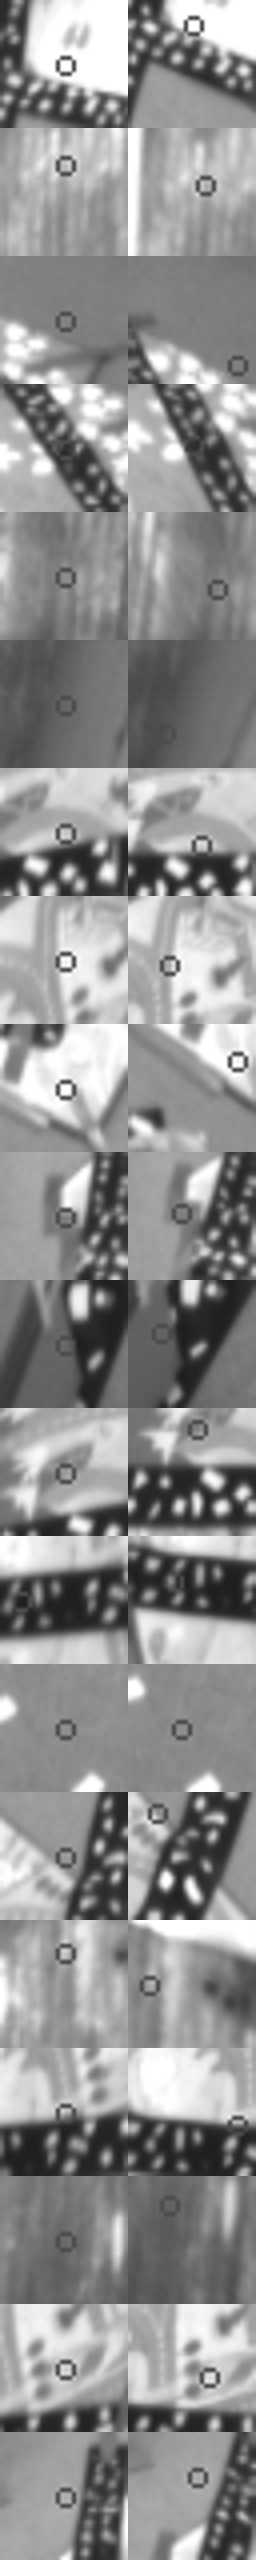

In [12]:
plot_first_image_from_batch(reference_patches, target_patches)

# Check Descriptor Model

In [13]:
if torch.cuda.is_available():
    reference_patches = reference_patches.cuda()
    target_patches = target_patches.cuda()

In [14]:
from model import KeypointDescriptorModel
model = KeypointDescriptorModel()

if torch.cuda.is_available():
    model = model.cuda()

In [15]:
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_trainable_params

593504

In [16]:
start_time = time.time()
reference_embeddings = model(reference_patches)
end_time = time.time()

print(f"Time taken for forward pass: {end_time - start_time:.6f} seconds")

start_time = time.time()
target_embeddings = model(target_patches)
end_time = time.time()

print(f"Time taken for forward pass: {end_time - start_time:.6f} seconds")

Time taken for forward pass: 0.195153 seconds
Time taken for forward pass: 0.004146 seconds


# Check Matcher

In [17]:
from model import KeypointMatcherModel
model = KeypointMatcherModel()

In [21]:
right_coords_pa_pred = model.match_keypoints(
    reference_embeddings, 
    target_embeddings, 
    left_coords_pa
)

right_coords_pa_pred.shape, right_coords_pa.shape

(torch.Size([4, 20, 2]), torch.Size([4, 20, 2]))

In [22]:
right_coords_pa[0, :5]

tensor([[16,  6],
        [19, 14],
        [27, 27],
        [16, 15],
        [22, 19]])

In [23]:
right_coords_pa_pred[0, :5]

tensor([[ 6, 16],
        [29, 30],
        [ 6, 29],
        [ 1, 28],
        [27, 21]], device='cuda:0')

In [27]:
# from utils import list_files_in_folder
# x = list_files_in_folder('/home/stud/ath/ath_ws/keypoint_matcher/data/matches/V1_01_easy/matches')
# len(x)

373